# Problem Statement:
- Build a Machine Learning regression model to predict a person's weight based on their height.
### Objective:
- Analyze the Height–Weight relationship and develop an accurate model for weight prediction.

### Import required packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost.dask import predict

### Load the dataset

In [ ]:
df = pd.read_csv("./height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


### EDA

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [ ]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated(keep=False)]

,Weight,Height
8,95,182
11,95,182


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

Weight    0
Height    0
dtype: int64

<Axes: xlabel='Height', ylabel='Weight'>

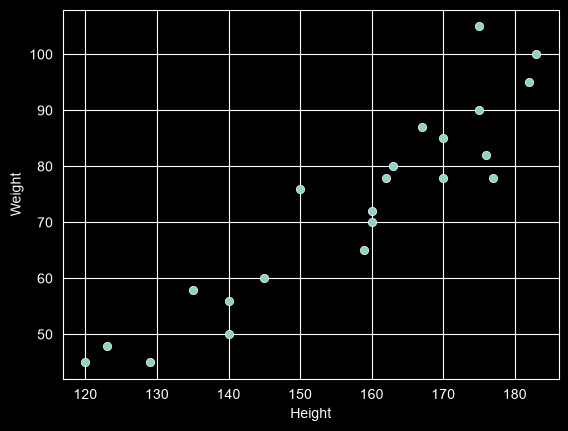

In [ ]:
sns.scatterplot(x='Height', y='Weight', data=df)

<Axes: >

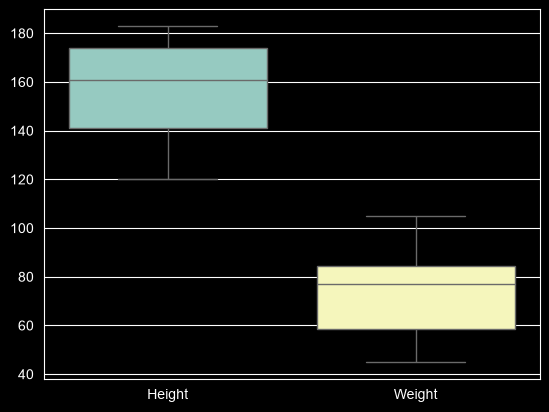

In [ ]:
sns.boxplot(data=df[['Height', 'Weight']])

In [ ]:
df.corr()

,Weight,Height
Weight,1.000000,0.926124
Height,0.926124,1.000000


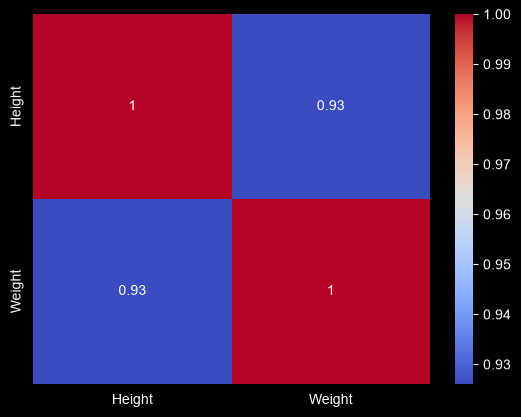

In [ ]:
sns.heatmap(df[['Height', 'Weight']].corr(), annot=True, cmap='coolwarm')
plt.show()

### split the data into x and y

In [ ]:
x = df.drop('Weight', axis=1)
y = df['Weight']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x , y , train_size=0.8 , random_state=42)

### Train the model

In [ ]:
from sklearn.linear_model import LinearRegression

#create a model
model=LinearRegression()

#train the model
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Height']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-60.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


### evaluate the model

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(x)

# get the r2 score
r2 = r2_score(y, y_pred)
print(f"r2 score = {r2:.2f}")

r2 score = 0.86


### Plot The Graph

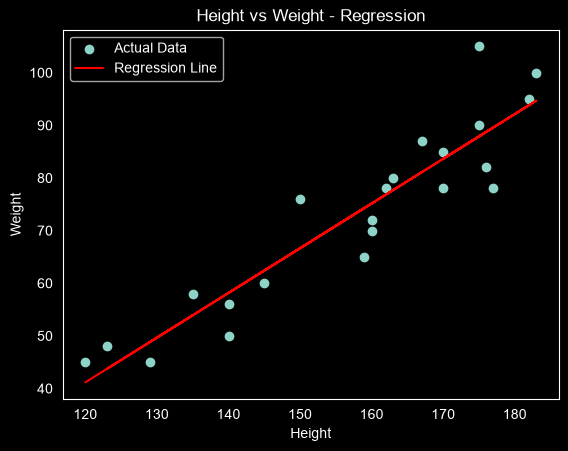

In [ ]:
plt.scatter(x['Height'], y, label="Actual Data")

plt.plot(x['Height'], y_pred, color="red", label="Regression Line")

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight - Regression")
plt.grid()
plt.legend()
plt.show()

### Inference the model

In [ ]:
new_data = pd.DataFrame({'Height': [175]})

predicted_weight = model.predict(new_data)

print(f"Predicted weight = {predicted_weight[0]:.2f} kg")

Predicted weight = 87.89 kg
